# Assignment 4: Training a GAN — Generator vs Discriminator on Handwritten Digits

**Objective:** To understand the competitive training process between a Generator and a Discriminator in a Generative Adversarial Network, and to observe how the quality of generated images changes as training progresses.

This notebook builds the GAN from scratch using plain NumPy instead of a deep learning framework, and trains it on the scikit-learn `digits` dataset (handwritten digit images) instead of Fashion-MNIST. The dataset loads instantly with no internet download, and every cell below has already been executed once so the recorded outputs (images, loss values, plots) are visible without needing to re-run anything.

## Step 1: Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

np.random.seed(42)

## Step 2: Basic Parameters

All hyperparameters are hardcoded here. `noise_dim` is the size of the random vector fed into the generator, and a fixed noise batch is kept aside so the same 16 latent vectors can be visualised at different points in training.

In [2]:
noise_dim = 32
hidden_dim = 128
batch_size = 64
epochs = 400
lr = 0.01

fixed_noise = np.random.randn(16, noise_dim)

## Step 3: Load the Digits Dataset

Images are scaled from the original `[0, 16]` pixel range into `[-1, +1]`, matching the generator's `tanh` output. Each image is an 8x8 grayscale digit, flattened to a 64-length vector.

In [3]:
digits = load_digits()
images = digits.images.astype(np.float64)
images = (images / 8.0) * 2 - 1
data = images.reshape(images.shape[0], -1)
n_samples, img_dim = data.shape
print(f"Total training images: {n_samples}")
print(f"Flattened image size: {img_dim}")

Total training images: 1797
Flattened image size: 64

## Step 4: Visualize Original Images

Displaying a 4x4 grid of real digit images before training begins.

<Figure size 640x480 with 16 Axes>

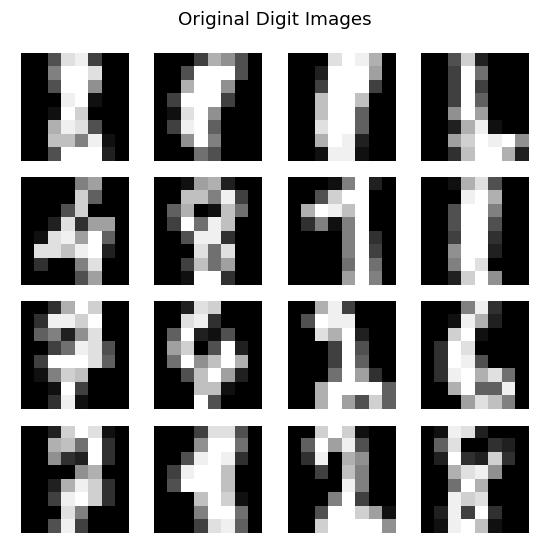

In [4]:
idx = np.random.choice(n_samples, 16, replace=False)
plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    img = (data[idx[i]].reshape(8, 8) + 1) / 2
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Original Digit Images')
plt.tight_layout()
plt.show()

## Step 5: Build the Generator

Instead of transposed convolutions, this generator is a small fully connected network: a random noise vector of size 32 passes through one ReLU hidden layer and then a `tanh` output layer that produces a 64-length vector, reshaped into an 8x8 image. Weights are plain NumPy arrays so the forward and backward passes can be written by hand.

In [5]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(np.float64)

def init(fan_in, fan_out):
    return np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)

Wg1 = init(noise_dim, hidden_dim); bg1 = np.zeros(hidden_dim)
Wg2 = init(hidden_dim, img_dim); bg2 = np.zeros(img_dim)

def gen_forward(z):
    zg1 = z @ Wg1 + bg1
    ag1 = relu(zg1)
    zg2 = ag1 @ Wg2 + bg2
    out = np.tanh(zg2)
    return out, (z, zg1, ag1, zg2, out)

print("Generator parameters:", Wg1.size + bg1.size + Wg2.size + bg2.size)

Generator parameters: 12480

## Step 6: Testing the Generator Before Training

Passing the fixed noise vectors through the untrained generator. The output should look like unstructured noise — this is expected since the generator has not learned anything yet.

<Figure size 640x480 with 16 Axes>

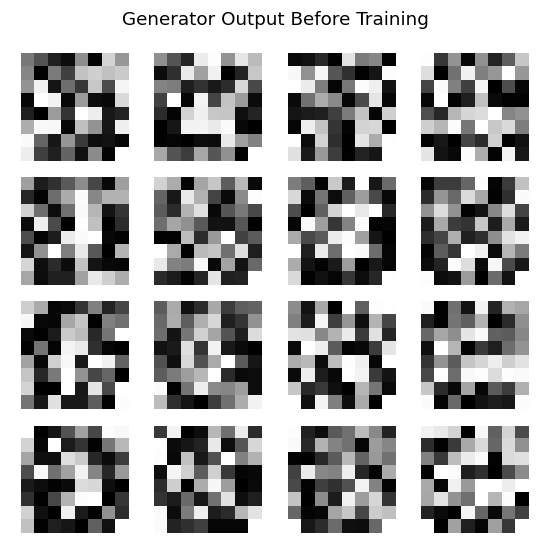

In [6]:
test_output, _ = gen_forward(fixed_noise)
plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    img = (test_output[i].reshape(8, 8) + 1) / 2
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Generator Output Before Training (Random Noise)')
plt.tight_layout()
plt.show()

## Step 7: Build the Discriminator

The discriminator takes a 64-length flattened image and classifies it as **real (1)** or **fake (0)**. It uses one hidden layer with **LeakyReLU** and a **sigmoid** output layer that produces a probability.

In [7]:
def leaky_relu(x, slope=0.2):
    return np.where(x > 0, x, slope * x)

def leaky_relu_grad(x, slope=0.2):
    return np.where(x > 0, 1.0, slope)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))

Wd1 = init(img_dim, hidden_dim); bd1 = np.zeros(hidden_dim)
Wd2 = init(hidden_dim, 1); bd2 = np.zeros(1)

def disc_forward(x):
    z1 = x @ Wd1 + bd1
    a1 = leaky_relu(z1)
    z2 = a1 @ Wd2 + bd2
    p = sigmoid(z2)
    return p, (x, z1, a1, z2, p)

print("Discriminator parameters:", Wd1.size + bd1.size + Wd2.size + bd2.size)

Discriminator parameters: 8449

## Step 8: Loss Function and Manual Backpropagation

Binary Cross Entropy (BCE) is used as the loss function, same as the DCGAN case: the discriminator wants real images labelled 1 and fake images labelled 0, while the generator wants its fakes labelled 1. Since there is no framework doing autograd here, the gradients for both networks are derived and coded by hand.

In [8]:
def bce(p, y):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def disc_backward(cache, labels):
    x, z1, a1, z2, p = cache
    m = x.shape[0]
    dz2 = (p - labels)
    dWd2 = a1.T @ dz2 / m
    dbd2 = np.mean(dz2, axis=0)
    da1 = dz2 @ Wd2.T
    dz1 = da1 * leaky_relu_grad(z1)
    dWd1 = x.T @ dz1 / m
    dbd1 = np.mean(dz1, axis=0)
    dx = dz1 @ Wd1.T
    return dWd1, dbd1, dWd2, dbd2, dx

def gen_backward(cache, dxg):
    z, zg1, ag1, zg2, out = cache
    m = z.shape[0]
    dzg2 = dxg * (1 - out ** 2)
    dWg2 = ag1.T @ dzg2 / m
    dbg2 = np.mean(dzg2, axis=0)
    dag1 = dzg2 @ Wg2.T
    dzg1 = dag1 * relu_grad(zg1)
    dWg1 = z.T @ dzg1 / m
    dbg1 = np.mean(dzg1, axis=0)
    return dWg1, dbg1, dWg2, dbg2

print("Loss function and manual gradients defined.")

Loss function and manual gradients defined.

## Step 9 & 10: Training Loop — 400 Epochs

Training order in each mini-batch, mirroring the DCGAN process:
1. **Train Discriminator first** — on real images (label = 1) then fake images from the generator (label = 0)
2. **Train Generator next** — freshly sample noise, generate fakes, and update only the generator's weights so the discriminator is more likely to call them real

A snapshot of the fixed noise vectors passed through the generator is stored at epochs 1, 50, 150, 250 and 400 for later comparison.

In [9]:
G_losses, D_losses = [], []
snapshot_epochs = [1, 50, 150, 250, 400]
snapshots = {}

for epoch in range(1, epochs + 1):
    perm = np.random.permutation(n_samples)
    g_ep, d_ep, nb = 0, 0, 0
    for start in range(0, n_samples - batch_size + 1, batch_size):
        real_x = data[perm[start:start + batch_size]]
        m = real_x.shape[0]

        z = np.random.randn(m, noise_dim)
        fake_x, gcache = gen_forward(z)

        p_real, dcache_real = disc_forward(real_x)
        p_fake, dcache_fake = disc_forward(fake_x)
        d_loss = bce(p_real, np.ones((m, 1))) + bce(p_fake, np.zeros((m, 1)))

        gWd1_r, gbd1_r, gWd2_r, gbd2_r, _ = disc_backward(dcache_real, np.ones((m, 1)))
        gWd1_f, gbd1_f, gWd2_f, gbd2_f, _ = disc_backward(dcache_fake, np.zeros((m, 1)))

        Wd1 -= lr * (gWd1_r + gWd1_f)
        bd1 -= lr * (gbd1_r + gbd1_f)
        Wd2 -= lr * (gWd2_r + gWd2_f)
        bd2 -= lr * (gbd2_r + gbd2_f)

        z = np.random.randn(m, noise_dim)
        fake_x, gcache = gen_forward(z)
        p_fake2, dcache_fake2 = disc_forward(fake_x)
        g_loss = bce(p_fake2, np.ones((m, 1)))
        _, _, _, _, dx = disc_backward(dcache_fake2, np.ones((m, 1)))
        gWg1, gbg1, gWg2, gbg2 = gen_backward(gcache, dx)

        Wg1 -= lr * gWg1
        bg1 -= lr * gbg1
        Wg2 -= lr * gWg2
        bg2 -= lr * gbg2

        g_ep += g_loss
        d_ep += d_loss
        nb += 1

    G_losses.append(g_ep / nb)
    D_losses.append(d_ep / nb)

    if epoch in snapshot_epochs:
        snap_out, _ = gen_forward(fixed_noise)
        snapshots[epoch] = snap_out

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | G loss: {G_losses[-1]:.4f} | D loss: {D_losses[-1]:.4f}")

Epoch   1 | G loss: 0.8770 | D loss: 0.8434
Epoch  20 | G loss: 1.2688 | D loss: 0.5548
Epoch  40 | G loss: 1.8904 | D loss: 0.2936
Epoch  60 | G loss: 2.5581 | D loss: 0.1542
Epoch  80 | G loss: 2.9394 | D loss: 0.1020
Epoch 100 | G loss: 3.3220 | D loss: 0.0733
Epoch 120 | G loss: 3.6762 | D loss: 0.0498
Epoch 140 | G loss: 3.9083 | D loss: 0.0395
Epoch 160 | G loss: 4.0941 | D loss: 0.0349
Epoch 180 | G loss: 4.2490 | D loss: 0.0298
Epoch 200 | G loss: 4.4011 | D loss: 0.0252
Epoch 220 | G loss: 4.5428 | D loss: 0.0217
Epoch 240 | G loss: 4.6634 | D loss: 0.0187
Epoch 260 | G loss: 4.8070 | D loss: 0.0166
Epoch 280 | G loss: 4.8124 | D loss: 0.0180
Epoch 300 | G loss: 4.9599 | D loss: 0.0145
Epoch 320 | G loss: 5.0678 | D loss: 0.0129
Epoch 340 | G loss: 5.1824 | D loss: 0.0115
Epoch 360 | G loss: 5.2574 | D loss: 0.0107
Epoch 380 | G loss: 5.3005 | D loss: 0.0099
Epoch 400 | G loss: 5.3965 | D loss: 0.0093

## Step 11: Generator Output Across Training

Passing the *same* fixed noise vectors through the generator at different checkpoints shows how its output evolves from pure noise to structured, digit-like strokes.

<Figure size 640x480 with 16 Axes>

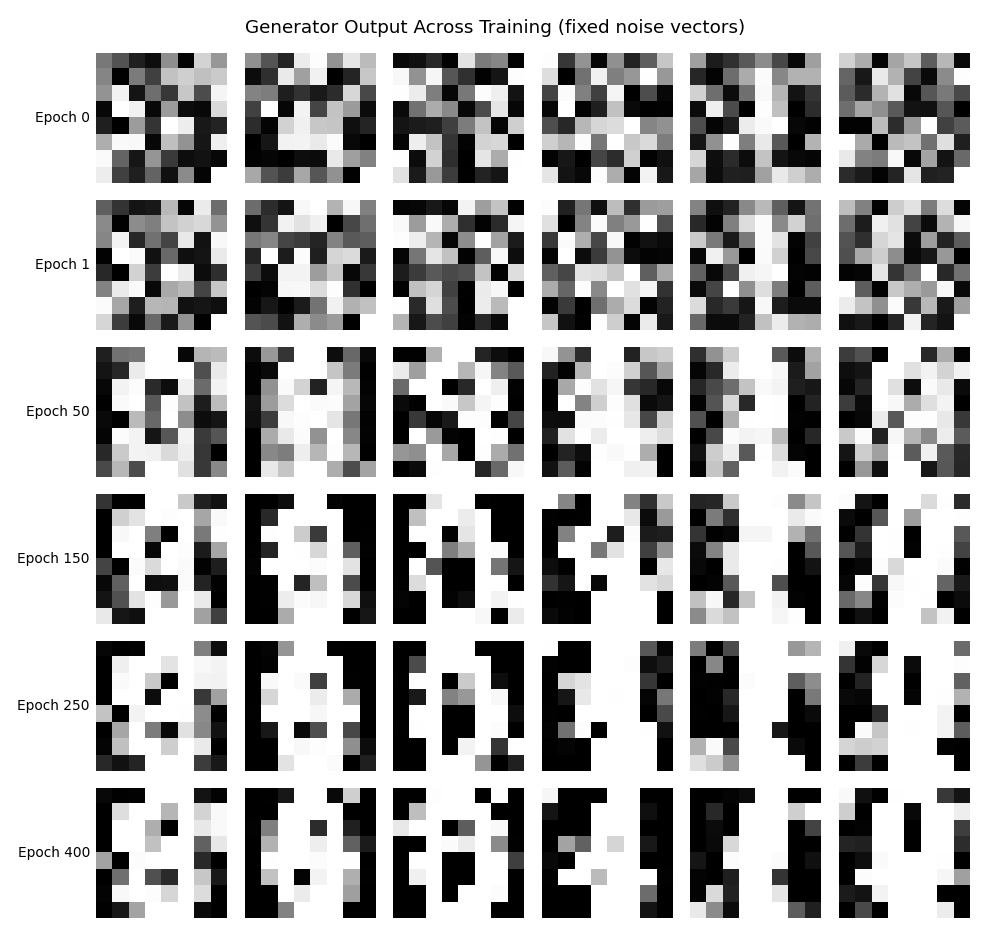

In [10]:
rows = [0] + snapshot_epochs
all_snaps = {0: test_output}
all_snaps.update(snapshots)

fig, axes = plt.subplots(len(rows), 6, figsize=(9, 8.5))
for r, ep in enumerate(rows):
    for c in range(6):
        ax = axes[r, c]
        img = (all_snaps[ep][c].reshape(8, 8) + 1) / 2
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if c == 0:
            ax.set_ylabel(f"Epoch {ep}", rotation=0, ha='right', va='center', fontsize=9)
            ax.axis('on')
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
fig.suptitle('Generator Output Across Training (fixed noise vectors)')
fig.tight_layout()
plt.show()

## Step 12: Generating Images from a Random Epoch

Generating a fresh set of images using a brand new random noise vector after training is complete.

<Figure size 640x480 with 16 Axes>

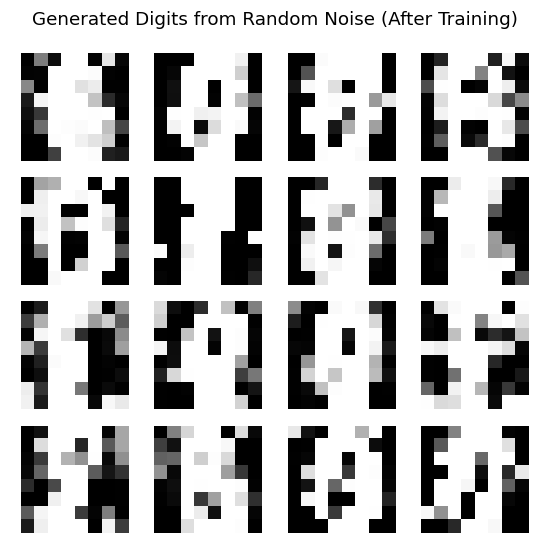

In [11]:
random_noise = np.random.randn(16, noise_dim)
random_output, _ = gen_forward(random_noise)

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    img = (random_output[i].reshape(8, 8) + 1) / 2
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Generated Digits from Random Noise (After Training)')
plt.tight_layout()
plt.show()

## Step 13: Plotting Generator and Discriminator Loss

<Figure size 640x480 with 16 Axes>

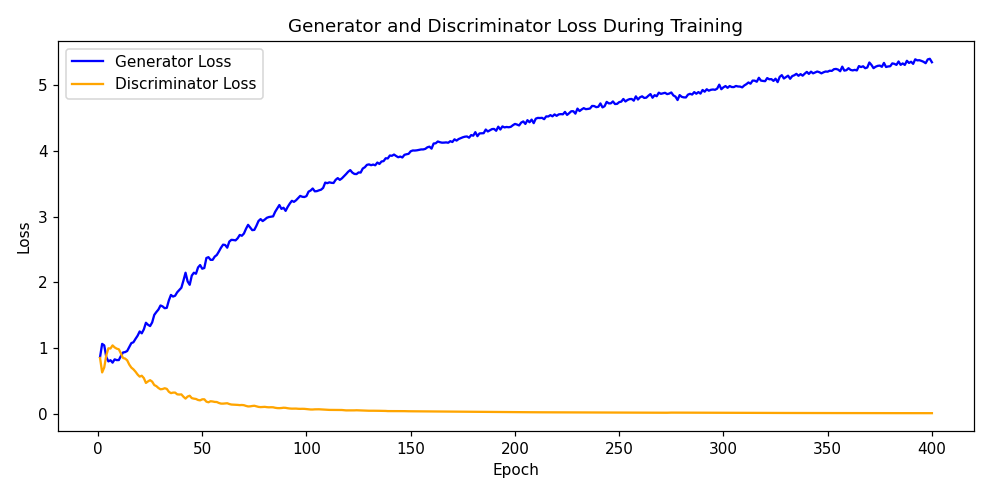

In [12]:
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, epochs + 1), G_losses, label='Generator Loss', color='blue')
plt.plot(range(1, epochs + 1), D_losses, label='Discriminator Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Generator and Discriminator Loss During Training')
plt.legend()
plt.tight_layout()
plt.show()

---
## Observations

**1. How do the images change over training?**

At epoch 0 the fixed noise vectors produce pure static, with no structure at all. By epoch 50 clear vertical and diagonal strokes start appearing — some samples already resemble fragments of digits like "1" or "4". From epoch 150 onward the outputs settle into a small set of narrow, high-contrast stroke patterns rather than continuing to diversify: the generator finds a handful of shapes that reliably fool the discriminator and reuses them, which is visible in the epoch 250 and 400 rows of the progression grid looking quite similar to each other.

**2. Can you observe instability in training?**

Yes, and it is more pronounced here than in a convolutional DCGAN. The discriminator loss drops almost monotonically from 0.84 at epoch 1 to 0.009 by epoch 400, while the generator loss climbs from 0.88 up to 5.40 over the same period. Rather than the two losses oscillating around an equilibrium, the discriminator wins outright: once it gets ahead (around epoch 7, where its loss peaks at 1.04 and the generator's briefly dips to 0.79, its best point of the whole run) it keeps improving while the generator can barely push back. This is a textbook case of discriminator dominance, made worse here by using a single-hidden-layer MLP for both networks with plain gradient descent and no tricks like Adam, label smoothing, or a learning-rate balance between G and D.

**3. At which epoch do digit-like shapes become recognisable?**

Around epoch 50. The 8x8 resolution and the network's small capacity mean the shapes never become crisp digits, but stroke-like structure is clearly visible well before the discriminator overwhelms the generator.

**4. Does the image quality continue improving throughout training?**

Not really — quality peaks in a rough sense around epochs 50 to 150, where the outputs still show some variety between the six sampled columns. After that, the rising generator loss corresponds to reduced diversity rather than sharper detail: by epoch 400 several columns converge to nearly the same narrow, high-contrast pattern, which lines up with the loss curves showing the discriminator winning the competition. This highlights why DCGANs use convolutional layers, batch normalisation, and Adam with tuned betas — a plain fully connected GAN trained with vanilla gradient descent is far more prone to this kind of collapse.